In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [2]:
import os

DATA_DIR = "/content/work"
RUNS_DIR = os.path.join(DATA_DIR, "step5_runs")
CKPT_DIR = os.path.join(RUNS_DIR, "checkpoints")
CONF_DIR = os.path.join(DATA_DIR, "configs")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(CONF_DIR, exist_ok=True)

CITY_CKPT = os.path.join(DATA_DIR, "eomt_cityscapes.bin")
COCO_CKPT = os.path.join(DATA_DIR, "eomt_coco.bin")

# STEP5: fine-tuned checkpoint
FT_CKPT = os.path.join(
    DATA_DIR,
    "step5_runs",
    "checkpoints",
    "best.ckpt",
)

print("DATA_DIR:", DATA_DIR)
print("RUN_DIR:", RUNS_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("CITY_CKPT exists:", os.path.exists(CITY_CKPT))
print("COCO_CKPT exists:", os.path.exists(COCO_CKPT))

DATA_DIR: /content/work
RUN_DIR: /content/work/step5_runs
CKPT_DIR: /content/work/step5_runs/checkpoints
CITY_CKPT exists: True
COCO_CKPT exists: True


In [3]:
!git clone https://github.com/AlessandroMarinai/MaskArchitectureAnomaly_CourseProject.git /content/project

Cloning into '/content/project'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 131 (delta 14), reused 7 (delta 7), pack-reused 86 (from 4)
Receiving objects: 100% (131/131), 26.88 MiB | 28.85 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [5]:
import getpass

CITY_USER = input("Cityscapes username: ")
CITY_PASS = getpass.getpass("Cityscapes password: ")

Cityscapes username: belfo
Cityscapes password: ··········


In [6]:
!wget --keep-session-cookies \
  --save-cookies cookies.txt \
  --post-data "username=$CITY_USER&password=$CITY_PASS&submit=Login" \
  "https://www.cityscapes-dataset.com/login/" \
  -O login_response.html

!wget -c --load-cookies cookies.txt --content-disposition \
  "https://www.cityscapes-dataset.com/file-handling/?packageID=1" \
  -O /content/work/gtFine_trainvaltest.zip

!wget -c --load-cookies cookies.txt --content-disposition \
  "https://www.cityscapes-dataset.com/file-handling/?packageID=3" \
  -O /content/work/leftImg8bit_trainvaltest.zip

--2026-04-25 12:06:17--  https://www.cityscapes-dataset.com/login/
Resolving www.cityscapes-dataset.com (www.cityscapes-dataset.com)... 139.19.217.8
Connecting to www.cityscapes-dataset.com (www.cityscapes-dataset.com)|139.19.217.8|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.cityscapes-dataset.com/downloads/ [following]
--2026-04-25 12:06:17--  https://www.cityscapes-dataset.com/downloads/
Reusing existing connection to www.cityscapes-dataset.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘login_response.html’

login_response.html     [ <=>                ]  55.82K  --.-KB/s    in 0.06s   

2026-04-25 12:06:17 (958 KB/s) - ‘login_response.html’ saved [57162]

--2026-04-25 12:06:17--  https://www.cityscapes-dataset.com/file-handling/?packageID=1
Resolving www.cityscapes-dataset.com (www.cityscapes-dataset.com)... 139.19.217.8
Connecting to www.cityscapes-dataset.com (www.cityscapes-dataset

In [7]:
!pip install -q gdown
!gdown --fuzzy "https://drive.google.com/file/d/1X57RfPr5FCemAIYAeNeev3AWPaW5Pjb1/view?usp=sharing" -O /content/work/eomt_cityscapes.bin
!gdown --fuzzy "https://drive.google.com/file/d/1fF-bevMQjDjCb15xDoYQGPpVqJZNY0XO/view?usp=sharing" -O /content/work/eomt_coco.bin
!gdown --fuzzy "https://drive.google.com/file/d/1F2JVlgxtjO2w3v-d7np7SUSUSx_5no5k/view?usp=sharing" -O /content/work/step5_runs/checkpoints/best.ckpt
#!gdown --fuzzy "https://drive.google.com/file/d/1_PXjlAL7Rw0qL4yP9oh783pfYHzinWai/view?usp=sharing" -O /content/work/step5_runs/checkpoints/last.ckpt
!gdown --fuzzy "https://drive.google.com/file/d/1hxo7ZxQZfgizeLQS5tqDpZu2b4xC5dkO/view?usp=sharing" -O /content/work/configs/eomt_base_640_from_coco_ft.yaml

Downloading...
From (original): https://drive.google.com/uc?id=1X57RfPr5FCemAIYAeNeev3AWPaW5Pjb1
From (redirected): https://drive.google.com/uc?id=1X57RfPr5FCemAIYAeNeev3AWPaW5Pjb1&confirm=t&uuid=1e9ea8dd-5deb-456f-bd47-2b97c80d77de
To: /content/work/eomt_cityscapes.bin
100% 382M/382M [00:03<00:00, 120MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1fF-bevMQjDjCb15xDoYQGPpVqJZNY0XO
From (redirected): https://drive.google.com/uc?id=1fF-bevMQjDjCb15xDoYQGPpVqJZNY0XO&confirm=t&uuid=df6d2a7b-513e-4260-aeb7-1e88b3165732
To: /content/work/eomt_coco.bin
100% 375M/375M [00:04<00:00, 93.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1F2JVlgxtjO2w3v-d7np7SUSUSx_5no5k
From (redirected): https://drive.google.com/uc?id=1F2JVlgxtjO2w3v-d7np7SUSUSx_5no5k&confirm=t&uuid=37fa9909-154b-4039-a96f-98ab0549d904
To: /content/work/step5_runs/checkpoints/best.ckpt
100% 1.12G/1.12G [00:06<00:00, 164MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1hxo7ZxQZf

In [8]:
%cd /content/project/eomt
!pip install -r requirements.txt

/content/project/eomt
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819

In [3]:
%cd /content/project/eomt

/content/project/eomt


# Setup

In [4]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0
img_idx = 0

# 2 configuration files, one for each model
city_config_path = "/content/project/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
coco_config_path = "/content/project/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"

# STEP5: fine-tuned model uses the Cityscapes semantic task/config
ft_config_path = "/content/work/configs/eomt_base_640_from_coco_ft.yaml"

data_path = "/content/work"

# we explicitly use the local checkpoints provided
city_ckpt_path = "/content/work/eomt_cityscapes.bin"
coco_ckpt_path = "/content/work/eomt_coco.bin"

ft_ckpt_path = "/content/work/step5_runs/checkpoints/best.ckpt"

with open(city_config_path, "r") as f:
    city_config = yaml.safe_load(f)

with open(coco_config_path, "r") as f:
    coco_config = yaml.safe_load(f)

# STEP5
with open(ft_config_path, "r") as f:
    ft_config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

# Debug
print("City config:", city_config_path)
print("COCO config:", coco_config_path)
print("Data path:", data_path)
print("City checkpoint exists:", os.path.exists(city_ckpt_path))
print("COCO checkpoint exists:", os.path.exists(coco_ckpt_path))
print("FT checkpoint exists:", os.path.exists(ft_ckpt_path))
print("Data path exists:", os.path.exists(data_path))

City config: /content/project/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml
COCO config: /content/project/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml
Data path: /content/work
City checkpoint exists: True
COCO checkpoint exists: True
FT checkpoint exists: True
Data path exists: True


# Load Cityscapes Validation Dataset

In [5]:
data_module_name, class_name = city_config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = city_config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

# Debug
print("Cityscapes val dataset loaded")
print("img_size:", data.img_size)
print("num_classes:", data.num_classes)
print("val size:", len(data.val_dataloader().dataset))

Cityscapes val dataset loaded
img_size: (1024, 1024)
num_classes: 19
val size: 500


# Utility Function: Load a Local Checkpoint

In the original notebook, model weights are downloaded from Hugging Face.
For this project, we already have the checkpoints stored locally, so we use a helper to load them

In [6]:
def load_local_state_dict(ckpt_path, map_location):
    state_dict = torch.load(ckpt_path, map_location=map_location)
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    return state_dict

# Function to build the model

We use a function to build either the Cityscapes model or the COCO model from a config file and a local checkpoint

In [7]:
def build_model(config, ckpt_path, num_classes, img_size):
    warnings.filterwarnings(
        "ignore",
        message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
    )

    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=img_size, **encoder_cfg.get("init_args", {}))

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    # If available, pass the list of "stuff" classes
    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = (
        lit_cls(
            img_size=img_size,
            num_classes=num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    # Load the pretrained weights from the local checkpoint
    state_dict = load_local_state_dict(ckpt_path, map_location=f"cuda:{device}")
    incompatible = model.load_state_dict(state_dict, strict=False)

    print(f"Loaded checkpoint: {ckpt_path}")
    print("Missing keys:", len(incompatible.missing_keys))
    print("Unexpected keys:", len(incompatible.unexpected_keys))

    return model

# Inspect COCO Model

In [8]:
coco_data_module_name, coco_class_name = coco_config["data"]["class_path"].rsplit(".", 1)
coco_data_module_cls = getattr(importlib.import_module(coco_data_module_name), coco_class_name)
coco_data_module_kwargs = coco_config["data"].get("init_args", {})

coco_data = coco_data_module_cls(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **coco_data_module_kwargs
)

# Debug
print("COCO metadata object created")
print("Possible num_classes:", getattr(coco_data, "num_classes", None))
print("Possible img_size:", getattr(coco_data, "img_size", None))
print("Possible stuff_classes:", getattr(coco_data, "stuff_classes", None))

COCO metadata object created
Possible num_classes: 133
Possible img_size: (640, 640)
Possible stuff_classes: None


# Build the 2 models

 Cityscapes Semantic Model

In [9]:
city_model = build_model(
    config=city_config,
    ckpt_path=city_ckpt_path,
    num_classes=data.num_classes,
    img_size=data.img_size,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loaded checkpoint: /content/work/eomt_cityscapes.bin
Missing keys: 0
Unexpected keys: 0


COCO Panoptic Model

In [10]:
# The COCO model must be rebuilt with its native image size so that
# the checkpoint positional embeddings match the model definition.
coco_num_classes = getattr(coco_data, "num_classes", None)

if coco_num_classes is None:
    raise ValueError("coco_data.num_classes is None. Dobbiamo recuperare il numero classi dal datamodule COCO.")

print("COCO img_size:", coco_data.img_size)

coco_model = build_model(
    config=coco_config,
    ckpt_path=coco_ckpt_path,
    num_classes=coco_num_classes,
    img_size=coco_data.img_size,
)

COCO img_size: (640, 640)
Loaded checkpoint: /content/work/eomt_coco.bin
Missing keys: 0
Unexpected keys: 0


# Step 5: Build the fine-tuned model

In [15]:
ft_model = build_model(
    config=ft_config,
    ckpt_path=ft_ckpt_path,
    num_classes=data.num_classes,
    img_size=coco_data.img_size,
)

Loaded checkpoint: /content/work/step5_runs/checkpoints/best.ckpt
Missing keys: 0
Unexpected keys: 0


# Semantic inference

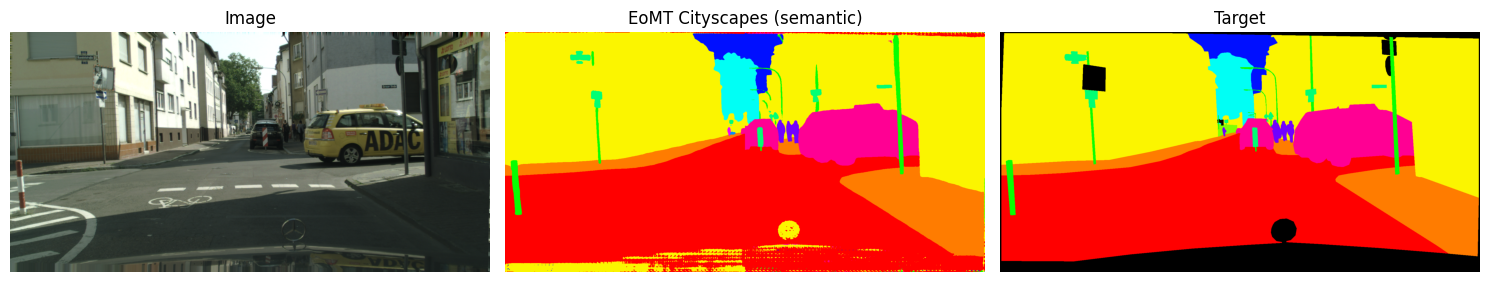

In [16]:
IGNORE_INDEX = 255

def infer_semantic(model, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)

        # we use the current image size
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()

    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array, title="Prediction"):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title(title)
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
city_pred_array, city_target_array = infer_semantic(city_model, img, target)
plot_semantic_results(img, city_pred_array, city_target_array, title="EoMT Cityscapes (semantic)")

# Panoptic inference

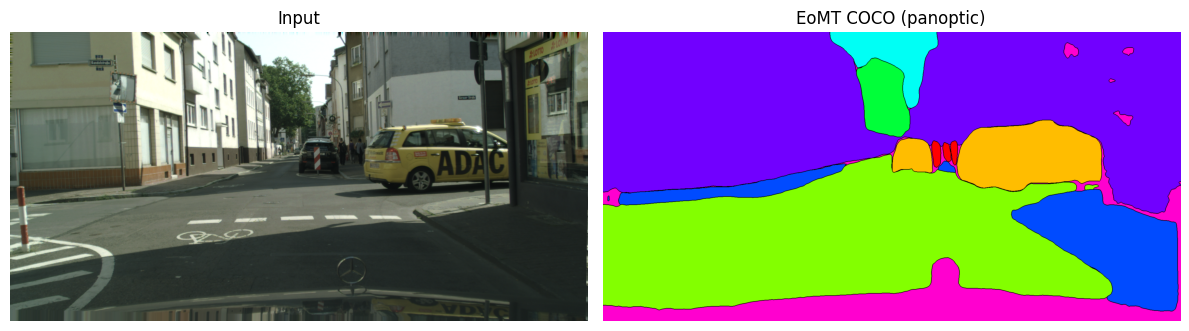

In [17]:
def infer_panoptic(model, img):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    return sem_pred, inst_pred


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, title="Prediction"):
    all_ids = np.unique(sem_pred)
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title(title)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


coco_sem_pred, coco_inst_pred = infer_panoptic(coco_model, img)
plot_panoptic_results(img, coco_sem_pred, coco_inst_pred, title="EoMT COCO (panoptic)")

# Step 5: Semantic inference for the fine-tuned model

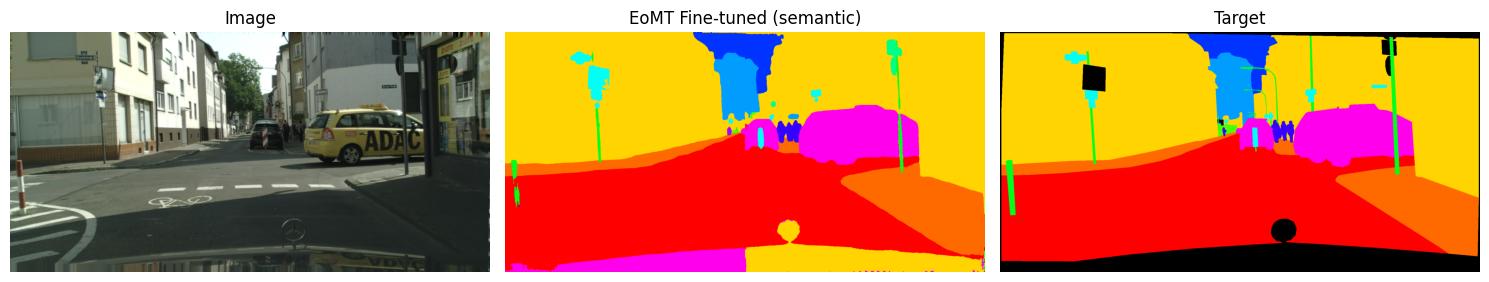

In [18]:
ft_pred_array, ft_target_array = infer_semantic(ft_model, img, target)
plot_semantic_results(img, ft_pred_array, ft_target_array, title="EoMT Fine-tuned (semantic)")

# Build the Cityscapes Label Mapping

The following block inspects the Cityscapes class definition provided by the repository in order to recover the official 'train_id -> class name' mapping

In [19]:
# from the file: MaskArchitectureAnomaly_CourseProject/eomt/datasets/cityscapes_semantic.py
from datasets.cityscapes_semantic import Cityscapes

# Debug
#for cls in Cityscapes.classes:
    #print(cls.id, cls.train_id, cls.name, cls.ignore_in_eval)

CITYSCAPES_TRAINID_TO_NAME = {
    cls.train_id: cls.name
    for cls in Cityscapes.classes
    if not cls.ignore_in_eval
}
print(CITYSCAPES_TRAINID_TO_NAME)

{0: 'road', 1: 'sidewalk', 2: 'building', 3: 'wall', 4: 'fence', 5: 'pole', 6: 'traffic light', 7: 'traffic sign', 8: 'vegetation', 9: 'terrain', 10: 'sky', 11: 'person', 12: 'rider', 13: 'car', 14: 'truck', 15: 'bus', 16: 'train', 17: 'motorcycle', 18: 'bicycle'}


Map Cityscapes Train_ID to the Shared/Common Evaluation Space.

The Common Classes are founded "manually" by exploring the 2 webisites of the 2 datasets

In [20]:
COMMON_CLASSES = ["person", "bicycle", "car", "motorcycle", "bus", "train", "truck", "traffic light"]
COMMON_TO_ID = {name: i for i, name in enumerate(COMMON_CLASSES)}

CITY_TO_COMMON = {
    11: COMMON_TO_ID["person"],
    18: COMMON_TO_ID["bicycle"],
    13: COMMON_TO_ID["car"],
    17: COMMON_TO_ID["motorcycle"],
    15: COMMON_TO_ID["bus"],
    16: COMMON_TO_ID["train"],
    14: COMMON_TO_ID["truck"],
    6:  COMMON_TO_ID["traffic light"],
}

print(COMMON_TO_ID)

{'person': 0, 'bicycle': 1, 'car': 2, 'motorcycle': 3, 'bus': 4, 'train': 5, 'truck': 6, 'traffic light': 7}


# Build the COCO Label Mapping



COCO category IDs were obtained from the official COCO dataset specification

In [21]:
COCO_ORIGINAL_IDS = {
    "person": 1,
    "bicycle": 2,
    "car": 3,
    "motorcycle": 4,
    "bus": 6,
    "train": 7,
    "truck": 8,
    "traffic light": 10,
}

# We directly use the standard IDs of COCO and the CLASS_MAPPING defined in coco_panoptic.py
import importlib

coco_module = importlib.import_module("datasets.coco_panoptic")

for name in dir(coco_module):
    if "MAP" in name.upper() or "CLASS" in name.upper():
        print(name)

COCO_CLASS_MAPPING = coco_module.CLASS_MAPPING
print(type(COCO_CLASS_MAPPING))
print(list(COCO_CLASS_MAPPING.items())[:10])

COCO_TO_COMMON = {
    COCO_CLASS_MAPPING[orig_id]: COMMON_TO_ID[name]
    for name, orig_id in COCO_ORIGINAL_IDS.items()
}

print("COCO_TO_COMMON =", COCO_TO_COMMON)

CLASS_MAPPING
<class 'dict'>
[(1, 0), (2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6), (8, 7), (9, 8), (10, 9)]
COCO_TO_COMMON = {0: 0, 1: 1, 2: 2, 3: 3, 5: 4, 6: 5, 7: 6, 9: 7}


# Remapping + Metric functions

In [22]:
# Remap a mask from its original label space (Cityscapes or COCO) into a common label space
def remap_mask(mask, mapping, ignore_label=255):

    # Create an output mask with the same shape as input, initialized with ignore_label (default: 255)
    out = np.full_like(mask, ignore_label)
    for msk, cls in mapping.items():
        out[mask == msk] = cls  # For all pixels where mask == msk, we assign the new class id (cls)
    return out


# Update a confusion matrix given predictions and targets
def update_confmat(confmat, pred, target, num_classes, ignore_label=255):

    # Select only valid pixels
    valid = target != ignore_label

    # Filter prediction and target using the previous mask
    pred = pred[valid]
    target = target[valid]

    for t, p in zip(target.reshape(-1), pred.reshape(-1)):
        if 0 <= t < num_classes and 0 <= p < num_classes:
            confmat[t, p] += 1  # increment confusion matrix cell:
                                # row = ground truth, column = prediction


# Compute per-class IoU from a confusion matrix
def compute_iou_from_confmat(confmat):
    ious = []
    for c in range(confmat.shape[0]):
        # True positives (TP): correctly predicted pixels
        tp = confmat[c, c]

        # False positives (FP): predicted as class c but GT is different
        fp = confmat[:, c].sum() - tp

        # False negatives (FN): GT is class c but predicted differently
        fn = confmat[c, :].sum() - tp

        # IoU denominator
        denom = tp + fp + fn

        # Handle division by zero (class not present)
        iou = np.nan if denom == 0 else tp / denom
        ious.append(iou)
    return np.array(ious)

# Common-Class Evaluation pipeline

In [23]:
from tqdm import tqdm  # debug

IGNORE_EVAL = 255                 # label to ignore pixels
num_common = len(COMMON_CLASSES)  # number of classes in the common evaluation space

# initialize confusion matrices for both models
conf_city = np.zeros((num_common, num_common), dtype=np.int64)
conf_coco = np.zeros((num_common, num_common), dtype=np.int64)
conf_ft = np.zeros((num_common, num_common), dtype=np.int64)     # Step 5

# Dataset: validation split from Cityscapes
val_dataset = data.val_dataloader().dataset

for idx in tqdm(range(len(val_dataset))):

    img, target = val_dataset[idx]

    # STEP 1: Run inference with both models
    # --------------------------------------------------------
    # Cityscapes model -> semantic inference
    pred_city_raw, target_city_raw = infer_semantic(city_model, img, target)

    # COCO model -> semantic inference
    pred_coco_raw, _ = infer_semantic(coco_model, img, target)

    # FT model -> semantic inference (Step 5)
    pred_ft_raw, _ = infer_semantic(ft_model, img, target)


    # STEP 2: Remap predictions and targets to common space
    # --------------------------------------------------------
    # Ground truth (Cityscapes) -> common label space
    target_common = remap_mask(target_city_raw, CITY_TO_COMMON, ignore_label=IGNORE_EVAL)

    # Cityscapes model predictions -> common label space
    pred_city_common = remap_mask(pred_city_raw, CITY_TO_COMMON, ignore_label=IGNORE_EVAL)

    # COCO model predictions -> common label space
    pred_coco_common = remap_mask(pred_coco_raw, COCO_TO_COMMON, ignore_label=IGNORE_EVAL)

    # FT model predictions -> common label space (Step 5)
    pred_ft_common = remap_mask(pred_ft_raw, CITY_TO_COMMON, ignore_label=IGNORE_EVAL)


    # STEP 3: Update confusion matrices
    # --------------------------------------------------------
    # Update confusion matrix for Cityscapes model
    update_confmat(conf_city, pred_city_common, target_common, num_common, ignore_label=IGNORE_EVAL)

    # Update confusion matrix for COCO model
    update_confmat(conf_coco, pred_coco_common, target_common, num_common, ignore_label=IGNORE_EVAL)

    # Update confusion matrix for FT model (Step 5)
    update_confmat(conf_ft, pred_ft_common, target_common, num_common, ignore_label=IGNORE_EVAL)


# COMPUTE IoU AND mIoU
ious_city = compute_iou_from_confmat(conf_city)
ious_coco = compute_iou_from_confmat(conf_coco)
ious_ft = compute_iou_from_confmat(conf_ft)

miou_city = np.nanmean(ious_city)
miou_coco = np.nanmean(ious_coco)
miou_ft = np.nanmean(ious_ft)     # Step 5

print("\n=== Common-class semantic evaluation on Cityscapes val ===")
print("Common classes:", COMMON_CLASSES)

print("\nPer-class IoU (Cityscapes model)")
for name, v in zip(COMMON_CLASSES, ious_city):
    print(f"{name:12s}: {v:.4f}")
print(f"EoMT Cityscapes mIoU: {miou_city:.4f}\n")

print("\nPer-class IoU (COCO model)")
for name, v in zip(COMMON_CLASSES, ious_coco):
    print(f"{name:12s}: {v:.4f}")
print(f"EoMT COCO mIoU: {miou_coco:.4f}")

# Step 5
print("\nPer-class IoU (Fine-tuned model)")
for name, v in zip(COMMON_CLASSES, ious_ft):
    print(f"{name:12s}: {v:.4f}")
print(f"EoMT Fine-tuned mIoU: {miou_ft:.4f}\n")

100%|██████████| 500/500 [12:03<00:00,  1.45s/it]


=== Common-class semantic evaluation on Cityscapes val ===
Common classes: ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'train', 'truck', 'traffic light']

Per-class IoU (Cityscapes model)
person      : 0.9724
bicycle     : 0.9504
car         : 0.9878
motorcycle  : 0.8526
bus         : 0.9507
train       : 0.9259
truck       : 0.8789
traffic light: 0.9979
EoMT Cityscapes mIoU: 0.9396


Per-class IoU (COCO model)
person      : 0.9410
bicycle     : 0.9073
car         : 0.8900
motorcycle  : 0.7793
bus         : 0.7591
train       : 0.1547
truck       : 0.3078
traffic light: 0.9957
EoMT COCO mIoU: 0.7169

Per-class IoU (Fine-tuned model)
person      : 0.9553
bicycle     : 0.9146
car         : 0.9634
motorcycle  : 0.6787
bus         : 0.6225
train       : 0.1839
truck       : 0.6483
traffic light: 0.9922
EoMT Fine-tuned mIoU: 0.7449

